# MNIST Digit Classification — Dense Network vs CNN

This notebook is organized as a step-by-step learning workflow:

1. **Load & explore the data**
2. **Baseline model** — a plain fully-connected (Dense) neural network
3. **CNN concepts** — stride, padding, pooling explained with examples
4. **CNN model** — build, train, and evaluate a Convolutional Neural Network
5. **Compare** the two approaches

The goal is not just to run the code, but to understand *why* each step and each layer exists.


## 1. Load the Data

We use the classic **MNIST** dataset: 70,000 grayscale images of handwritten digits (0–9), each 28×28 pixels.

In [1]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Check the shapes** — this tells us how many images we have and their dimensions.

| Variable | Meaning |
|---|---|
| `x_train` | 60,000 training images |
| `y_train` | labels (0–9) for training images |
| `x_test`  | 10,000 test images |
| `y_test`  | labels (0–9) for test images |

Each image is `28 × 28` pixels, stored as a 2D array of pixel intensities (0–255).


In [2]:
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


Let's peek at the raw pixel values of the first image, and then visualize it.

In [3]:
print(x_train[0])  # 28x28 grid of pixel values (0-255)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

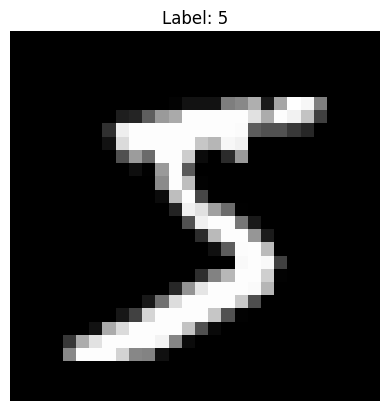

In [4]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

## 2. Preprocess the Data

**Normalization**: pixel values range from 0–255. Neural networks train faster and more
stably when inputs are on a small, consistent scale (here, 0–1), so we divide by 255.


In [5]:
# Normalize pixel values to the range [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

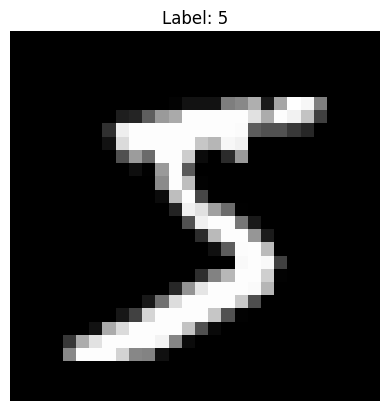

In [6]:
# Visualize again to confirm the image still looks the same (normalization doesn't change the picture)
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

## 3. Baseline Model — Plain Dense (Fully Connected) Network

Before building a CNN, it's useful to see how a simple, non-convolutional network performs.
This gives us a baseline to compare against later.

**How it works:**
- `Flatten` turns the 28×28 image into a single 784-length vector (a CNN keeps the 2D shape, this doesn't).
- `Dense(128, relu)` is a fully-connected hidden layer.
- `Dense(10, softmax)` outputs a probability for each of the 10 digit classes.

**Limitation of this approach:** flattening destroys spatial structure — the network never
explicitly learns that neighboring pixels form edges, curves, or shapes. It only sees a long
list of numbers. This is exactly the gap that CNNs are designed to fill (see Section 4).


In [7]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9181 - loss: 0.2860 - val_accuracy: 0.9542 - val_loss: 0.1591
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9616 - loss: 0.1313 - val_accuracy: 0.9571 - val_loss: 0.1372
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9734 - loss: 0.0877 - val_accuracy: 0.9723 - val_loss: 0.0913
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9805 - loss: 0.0647 - val_accuracy: 0.9726 - val_loss: 0.0935
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9845 - loss: 0.0493 - val_accuracy: 0.9766 - val_loss: 0.0835
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9885 - loss: 0.0378 - val_accuracy: 0.9731 - val_loss: 0.0922
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9911 - loss: 0.0301 - val_accuracy: 0.9751 - val_loss: 0.0867
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9926 - loss: 0.0242 - 

### Evaluate the baseline model

In [10]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [11]:
y_pred  # NOT class labels yet -- these are probabilities (one per class, per image)

array([[1.33594212e-11, 1.70335414e-17, 1.24244495e-11, ...,
        1.00000000e+00, 4.71779300e-13, 1.03649457e-12],
       [4.73748863e-16, 2.46464871e-09, 1.00000000e+00, ...,
        2.75793878e-24, 3.50652747e-17, 9.94860102e-30],
       [1.26782319e-12, 9.99999046e-01, 4.15556059e-07, ...,
        8.56040074e-08, 4.05844929e-07, 1.42790432e-15],
       ...,
       [5.54773992e-22, 2.92370186e-20, 7.04399787e-21, ...,
        2.40585763e-12, 1.32084759e-13, 2.59264321e-09],
       [1.05412893e-16, 1.15441981e-20, 5.30817438e-20, ...,
        1.62318959e-17, 9.35374261e-12, 1.51736945e-20],
       [5.74625518e-19, 6.70592859e-23, 7.06457592e-12, ...,
        5.75954646e-29, 2.83940320e-16, 1.42306246e-20]], dtype=float32)

In [12]:
from sklearn.metrics import classification_report
import numpy as np

# Convert probabilities to class labels (pick the class with the highest probability)
y_pred_labels = np.argmax(y_pred, axis=1)

# Classification report: precision, recall, f1-score per digit class
print(classification_report(y_test, y_pred_labels))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.95      0.99      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.97      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.99      0.95      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## 4. CNN Concepts — Stride, Padding, and Pooling

Before building the CNN, let's understand the key building blocks and **why** each one is used.

### 4.1 Convolution — the basic idea

A CNN slides a small matrix called a **filter / kernel** (e.g. 3×3) across the image.
At each position, it multiplies the filter values with the pixel values underneath and sums
them up, producing one number in the output **feature map**. This is how a CNN detects
patterns like edges, corners, and textures, while preserving spatial layout — something a
plain Dense layer (Section 3) cannot do.

---

### 4.2 Stride — how far the filter moves

**Stride** is the number of pixels the filter shifts each step (horizontally and vertically).

- **Stride = 1**: the filter moves one pixel at a time → output is almost as large as the
  input → captures fine detail, more computation.
- **Stride = 2**: the filter skips a pixel each step → output is roughly half the size →
  faster, fewer parameters downstream, but coarser detail.

**Why we use it:** stride controls how much the feature map is downsampled during the
convolution itself. A larger stride is a cheap way to shrink the data and reduce computation,
similar in effect to pooling (Section 4.4).

**Example** — 5×5 input, 3×3 filter:

```
Stride = 1                          Stride = 2
Input: 5x5  ->  Output: 3x3         Input: 5x5  ->  Output: 2x2
(filter moves 1 px at a time)       (filter moves 2 px at a time)
```

Formula for output size (no padding): `output = floor((input - filter) / stride) + 1`
- Stride 1: `(5-3)/1 + 1 = 3` → 3×3 output
- Stride 2: `(5-3)/2 + 1 = 2` → 2×2 output

---

### 4.3 Padding — preserving the borders

As the filter slides across an image, pixels near the edges get "seen" by the filter far
fewer times than pixels in the center — and every convolution shrinks the feature map a bit.
Stack several conv layers and the image would shrink very fast, losing edge information.

**Padding** adds a border of (usually zero-valued) pixels around the image before convolving.

- **`padding="valid"`** → no padding, output shrinks each layer (what we saw in 4.2's example).
- **`padding="same"`** → pads just enough so the output has the **same** width/height as the
  input (when stride = 1).

**Why we use it:** padding lets us control output size directly, keeps edge/corner
information from being under-represented, and lets us stack many conv layers without the
feature map vanishing to nothing.

---

### 4.4 Pooling — downsampling the feature map

**Pooling** slides a small window (e.g. 2×2) over the feature map and reduces each window to
a single number. Unlike convolution, there are no learnable weights — it's a fixed operation.

**Why we use it:**
- Reduces the size (and computation) of feature maps going into later layers.
- Reduces the number of parameters, which helps prevent overfitting.
- Adds a small amount of **translation invariance** — a feature shifting by a pixel or two
  still produces a similar pooled output.

There are three common types, differing in *how* the window is reduced to one number:

| Type | Operation | When it's used | Why |
|---|---|---|---|
| **Max pooling** | takes the **largest** value in the window | Most common, used in almost all CNNs (including this notebook) | Keeps the strongest activation — i.e. the most confidently detected feature (an edge, a stroke) — and discards weak/noisy responses. Great for detecting "is this pattern present, and where roughly?" |
| **Average pooling** | takes the **mean** of the window | Often used near the end of a network (e.g. Global Average Pooling before the classifier) | Smooths the feature map instead of picking one extreme value; keeps overall signal strength rather than just the peak. Less aggressive, can lose sharp/localized detail. |
| **Min pooling** | takes the **smallest** value in the window | Rare in practice | Highlights the least-activated / darkest region. Only useful in special cases (e.g. detecting the *absence* of a feature); not used in typical image classifiers. |

**Example** — a 4×4 feature map, pooled with a 2×2 window and stride 2 (non-overlapping):

```
Feature map:
 1   3   2   4
 5   6   1   2
 2   1   0   3
 4   2   1   1
```

Split into four 2×2 windows: top-left `[1,3,5,6]`, top-right `[2,4,1,2]`,
bottom-left `[2,1,4,2]`, bottom-right `[0,3,1,1]`.

| Pooling type | Result (2×2) |
|---|---|
| **Max** | `[[6, 4], [4, 3]]` — the largest value in each window |
| **Average** | `[[3.75, 2.25], [2.25, 1.25]]` — the mean of each window |
| **Min** | `[[1, 1], [1, 0]]` — the smallest value in each window |

Max pooling keeps `6`, the strongest activation, from the top-left window — this is why it's
preferred for classification: strong activations usually correspond to "this feature is
present here."

---

### 4.5 How these apply to *this* notebook

In the CNN built below:
- `Conv2D(32, kernel_size=(3,3), activation="relu")` — 32 filters, each 3×3, stride defaults
  to 1, padding defaults to `"valid"` → each conv layer shrinks the feature map slightly and
  produces 32 feature maps (one per filter).
- `MaxPooling2D(pool_size=(2,2))` — halves the height and width, keeping the strongest
  feature in each 2×2 window.
- This Conv → Pool pattern repeats twice, progressively extracting higher-level features
  (edges → strokes → digit shapes) while shrinking the spatial size and growing the number of
  filters (32 → 64).


## 5. Build the CNN Model

### 5.1 Reshape the data

A CNN's `Conv2D` layer expects input shaped as `(samples, height, width, channels)`.
Our MNIST data is currently `(60000, 28, 28)` — missing the channel dimension (`1` for
grayscale, `3` would mean RGB). We add that dimension with `reshape`.


In [13]:
import numpy as np

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape)
print(x_test.shape)  # the trailing 1 means grayscale (1 color channel)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


### 5.2 Define the architecture

Recall from Section 4: `Conv2D` layers extract features (edges, curves), `MaxPooling2D`
layers downsample while keeping the strongest signals, and the final `Dense` layers do the
actual classification once features are extracted.


In [14]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([

    # --- Feature extraction block 1 ---
    # 32 filters of size 3x3 -> learns 32 different low-level patterns (edges, corners)
    Conv2D(32, kernel_size=(3, 3), activation="relu",
           input_shape=(28, 28, 1)),

    # Downsample: keep the strongest activation in each 2x2 window (see Section 4.4)
    MaxPooling2D(pool_size=(2, 2)),

    # --- Feature extraction block 2 ---
    # 64 filters -> learns more complex, higher-level patterns built from block 1's features
    Conv2D(64, kernel_size=(3, 3), activation="relu"),

    MaxPooling2D(pool_size=(2, 2)),

    # Convert the 2D feature maps into a 1D vector for the classifier
    Flatten(),

    # Classification head
    Dense(128, activation="relu"),

    # 10 output units, one per digit (0-9)
    Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 5.3 Compile and train

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9419 - loss: 0.1902 - val_accuracy: 0.9758 - val_loss: 0.0804
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9820 - loss: 0.0572 - val_accuracy: 0.9847 - val_loss: 0.0504
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9885 - loss: 0.0365 - val_accuracy: 0.9839 - val_loss: 0.0558
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9911 - loss: 0.0290 - val_accuracy: 0.9844 - val_loss: 0.0559
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9928 - loss: 0.0225 - val_accuracy: 0.9887 - val_loss: 0.0374
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9944 - loss: 0.0166 - val_accuracy: 0.9867 - val_loss: 0.0450
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9951 - loss: 0.0136 - val_accuracy: 0.9874 - val_loss: 0.0486
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9968 - loss: 0.0102 - val_accuracy: 0.

### 5.4 Evaluate the CNN

In [18]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [19]:
from sklearn.metrics import classification_report
import numpy as np

# Convert probabilities to class labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Classification report
print(classification_report(y_test, y_pred_labels))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      0.99      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.97      1.00      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 6. Summary Notes

**Dense (baseline) network:**
- Flattens the image, so it loses spatial structure.
- Simple, fast to reason about, but typically less accurate on image data.

**CNN:**
- Preserves 2D spatial structure via `Conv2D`.
- **Stride** controls how far the filter moves each step → controls output size / detail vs. speed.
- **Padding** controls whether the output shrinks (`valid`) or stays the same size (`same`) → preserves border information and lets you stack more layers.
- **Pooling** downsamples the feature map:
  - **Max pooling** (used here) keeps the strongest feature signal → best for classification.
  - **Average pooling** smooths the signal → often used near the end of a network.
  - **Min pooling** keeps the weakest signal → rarely used in practice.
- Because it extracts local, spatially-aware features, a CNN typically outperforms a plain
  Dense network on image tasks like this one — compare the two `classification_report`
  outputs above to see the difference in practice.
